# Import Libraries

In [50]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

# Load Data

In [2]:
df = pd.read_csv('supply_chain_data.csv')
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


## Exploratory Data Analysis

In [3]:
df.shape

(100, 24)

In [4]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [5]:
df.nunique()

Product type                 3
SKU                        100
Price                      100
Availability                63
Number of products sold     96
Revenue generated          100
Customer demographics        4
Stock levels                65
Lead times                  29
Order quantities            61
Shipping times              10
Shipping carriers            3
Shipping costs             100
Supplier name                5
Location                     5
Lead time                   29
Production volumes          96
Manufacturing lead time     30
Manufacturing costs        100
Inspection results           3
Defect rates               100
Transportation modes         4
Routes                       3
Costs                      100
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [7]:
df.isna().sum()

Product type               0
SKU                        0
Price                      0
Availability               0
Number of products sold    0
Revenue generated          0
Customer demographics      0
Stock levels               0
Lead times                 0
Order quantities           0
Shipping times             0
Shipping carriers          0
Shipping costs             0
Supplier name              0
Location                   0
Lead time                  0
Production volumes         0
Manufacturing lead time    0
Manufacturing costs        0
Inspection results         0
Defect rates               0
Transportation modes       0
Routes                     0
Costs                      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.fillna(0, inplace=True)
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864


In [11]:
num_cols = ['Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 
            'Defect rates', 'Costs']

cat_cols = ['Product type', 'SKU', 'Customer demographics', 'Shipping carriers', 'Supplier name', 'Location', 'Inspection results', 'Transportation modes', 'Routes']

print(len(num_cols))
print(len(cat_cols))

15
9


## Visualization

### 1. Histogram Of Num_Cols

<Figure size 1200x600 with 0 Axes>

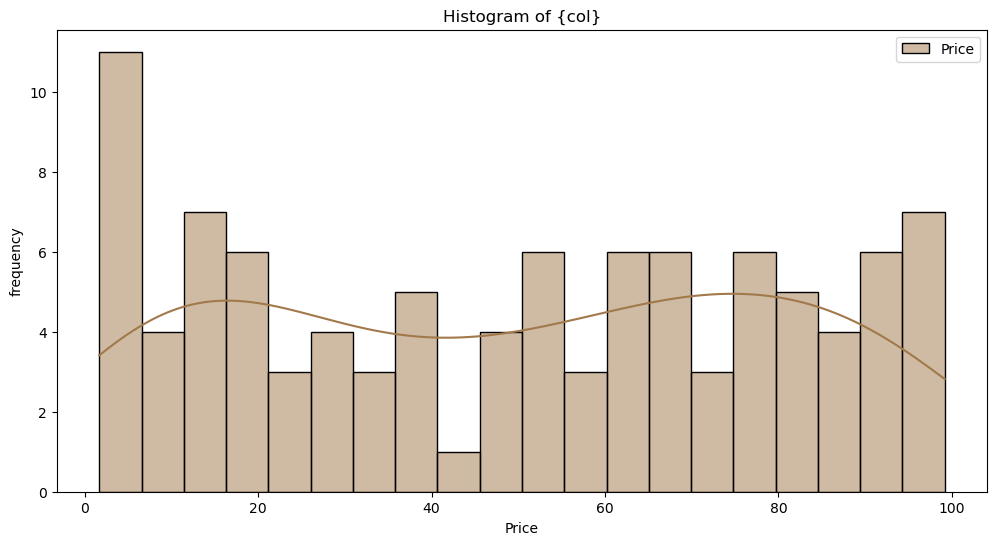

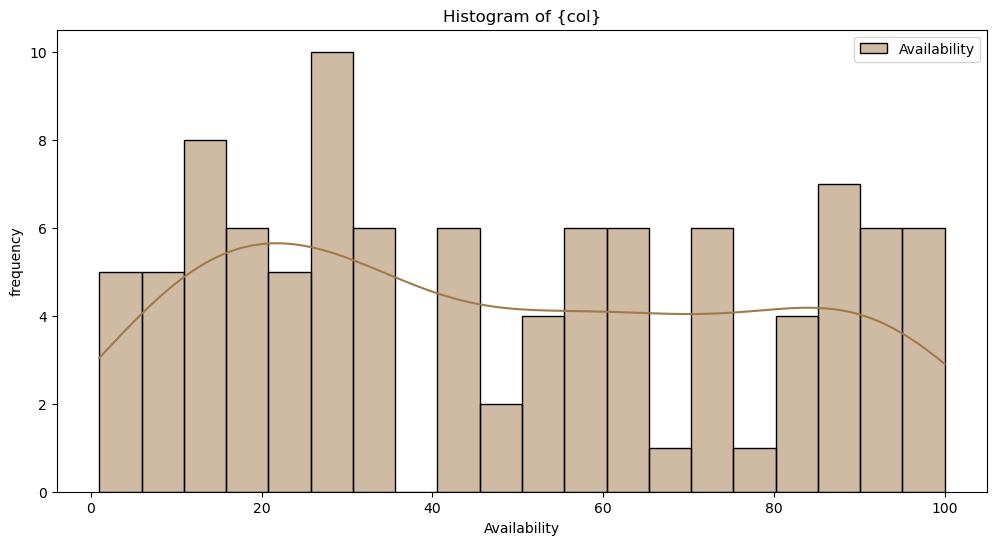

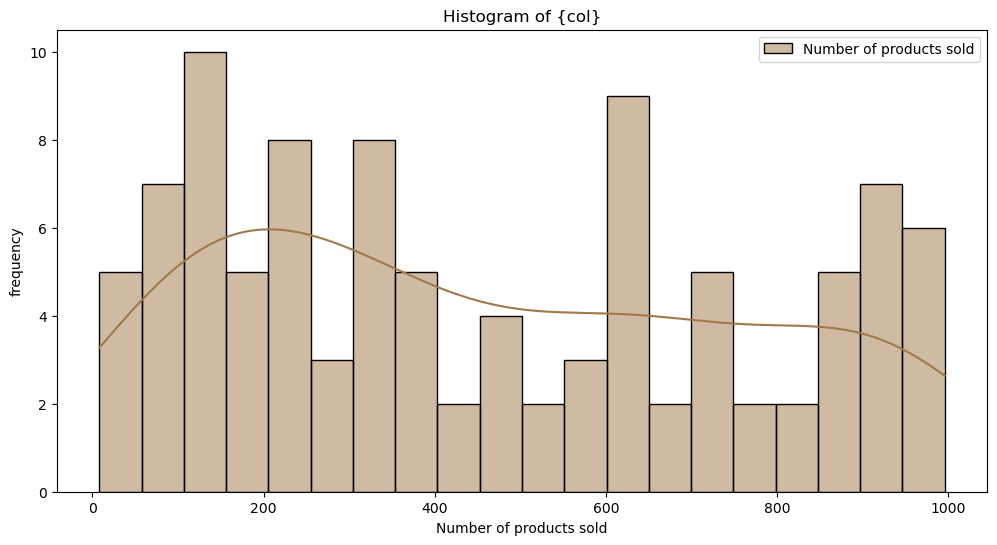

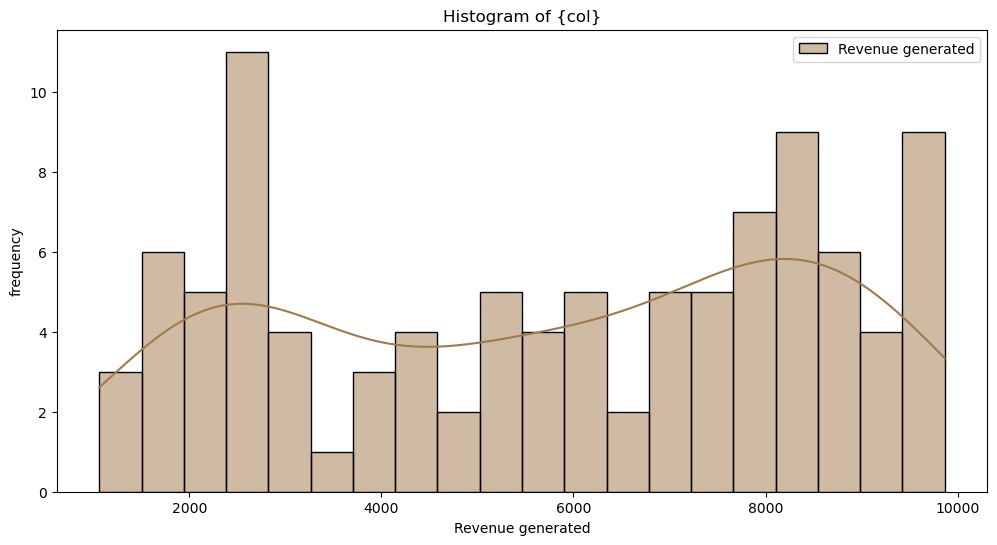

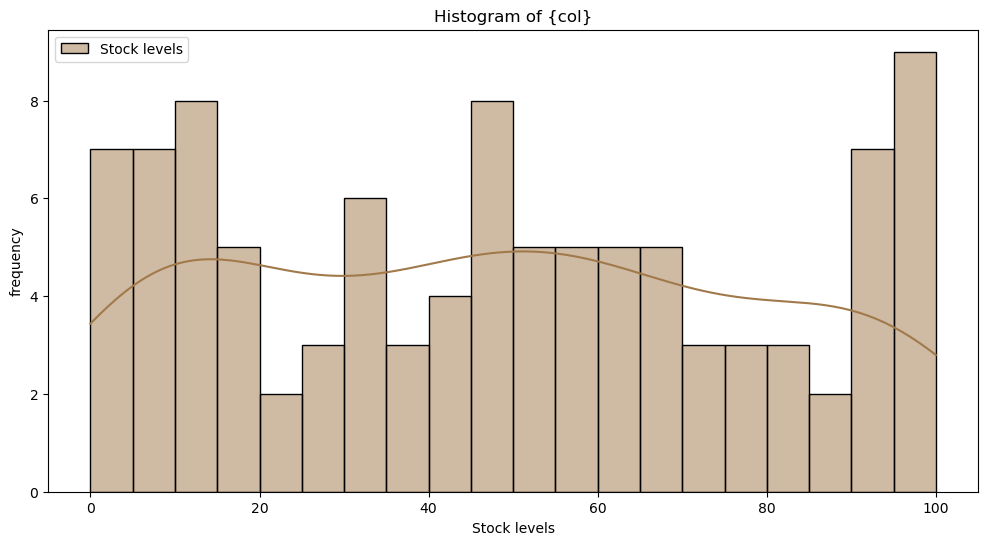

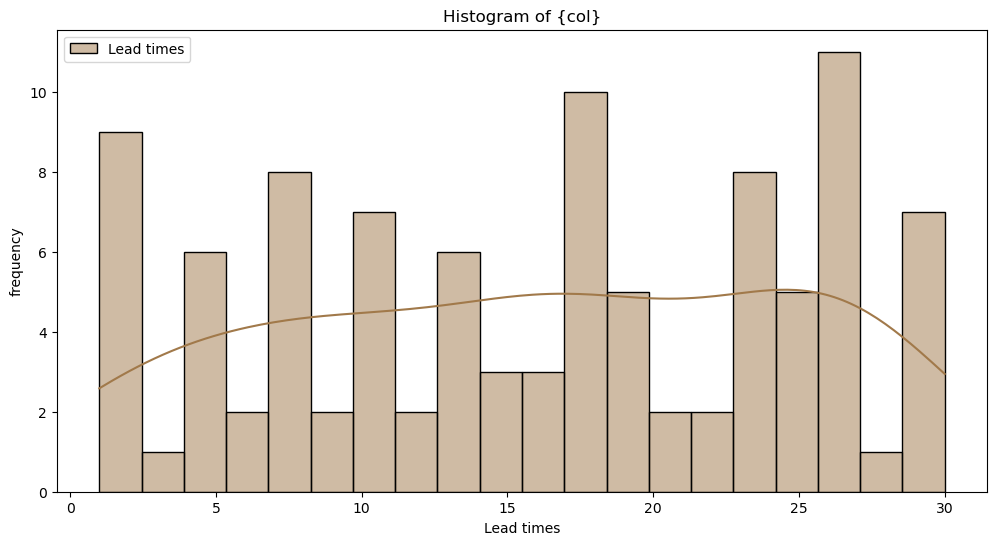

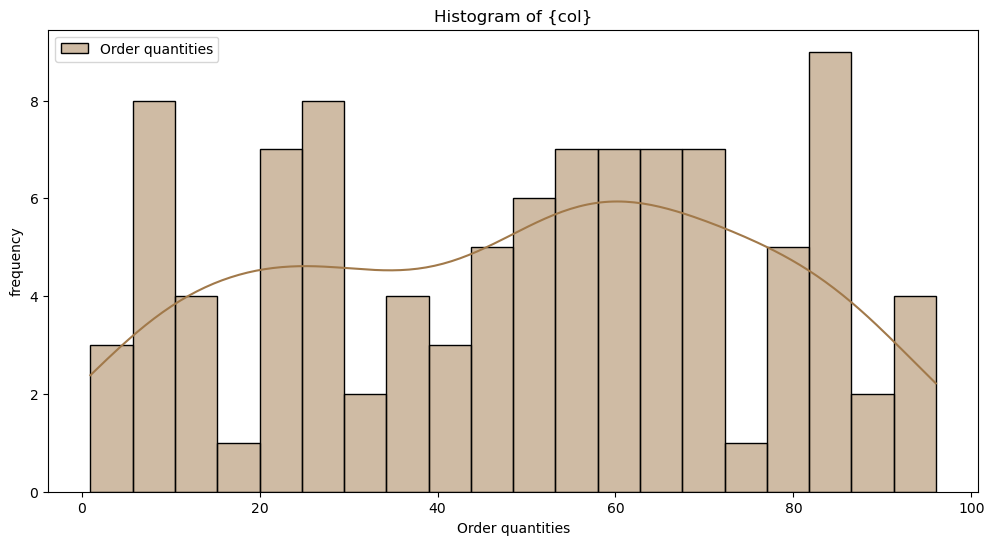

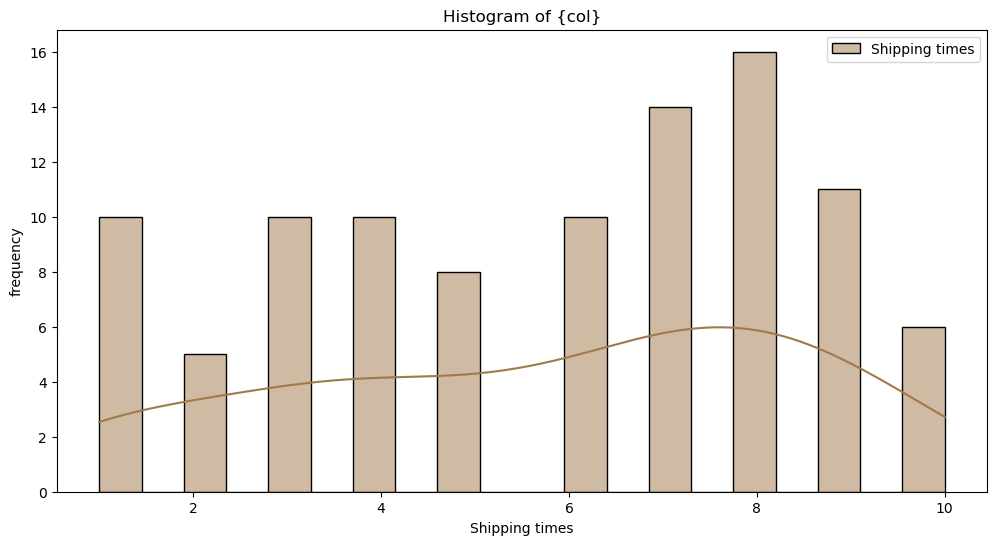

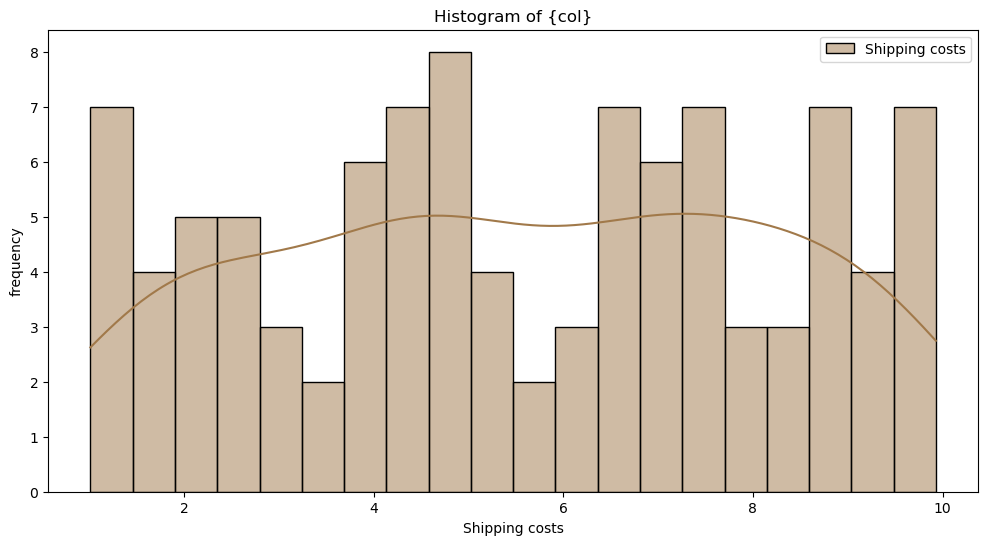

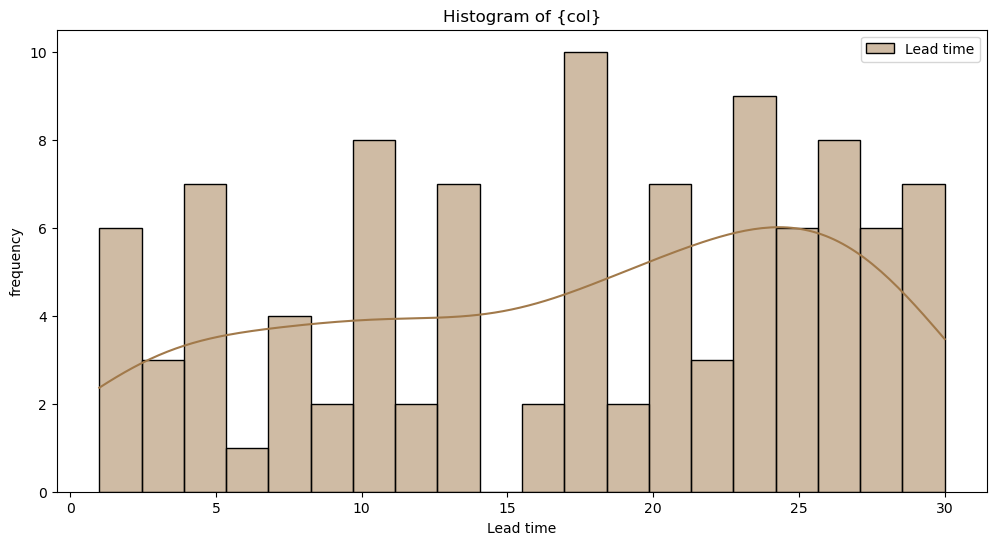

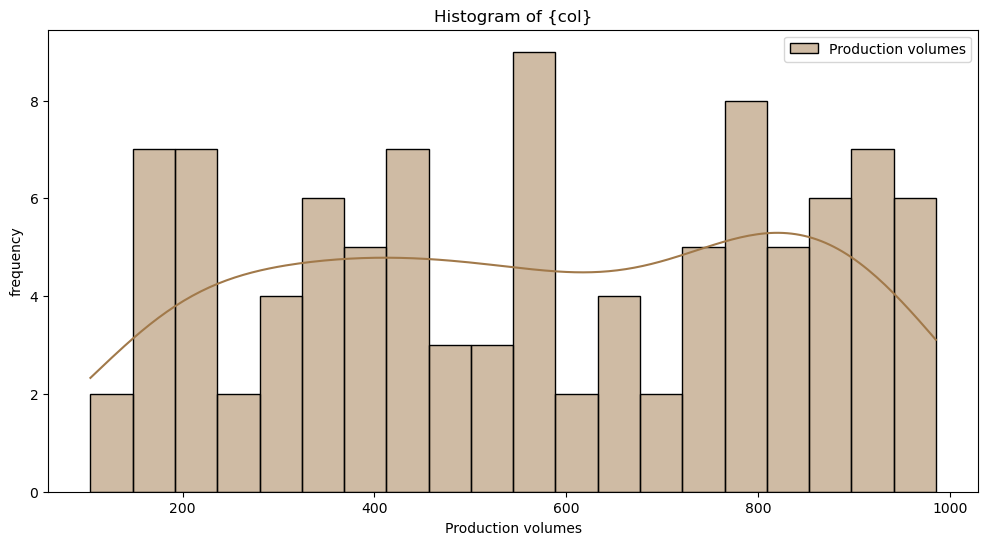

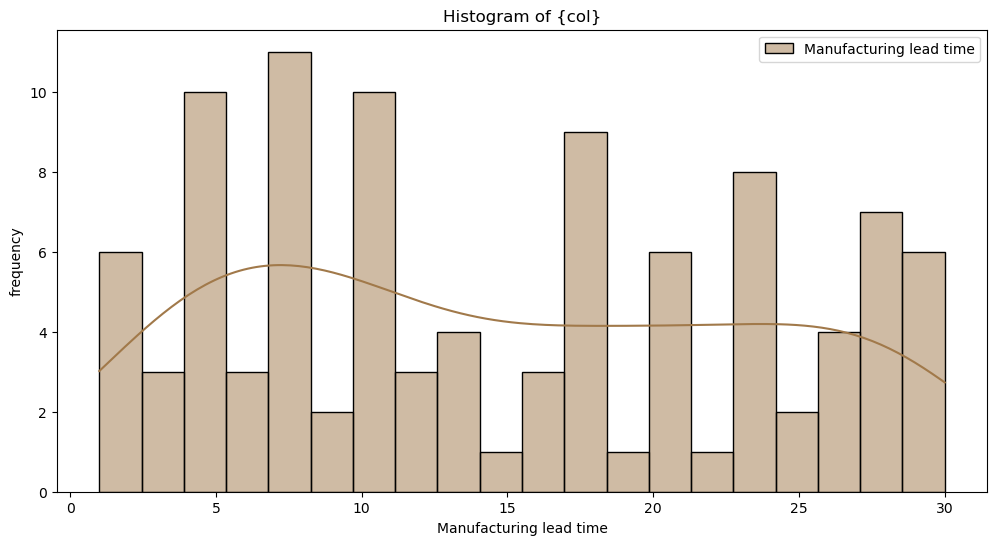

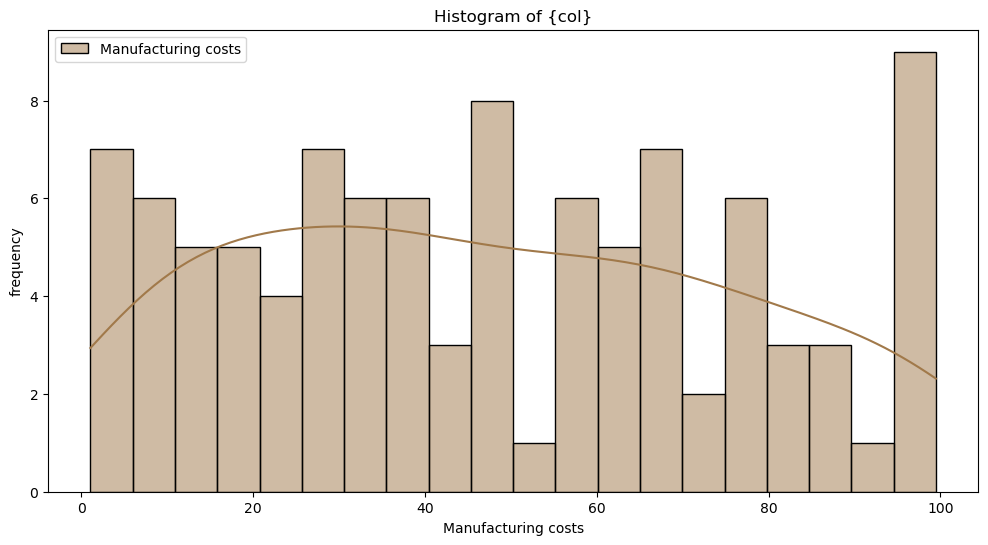

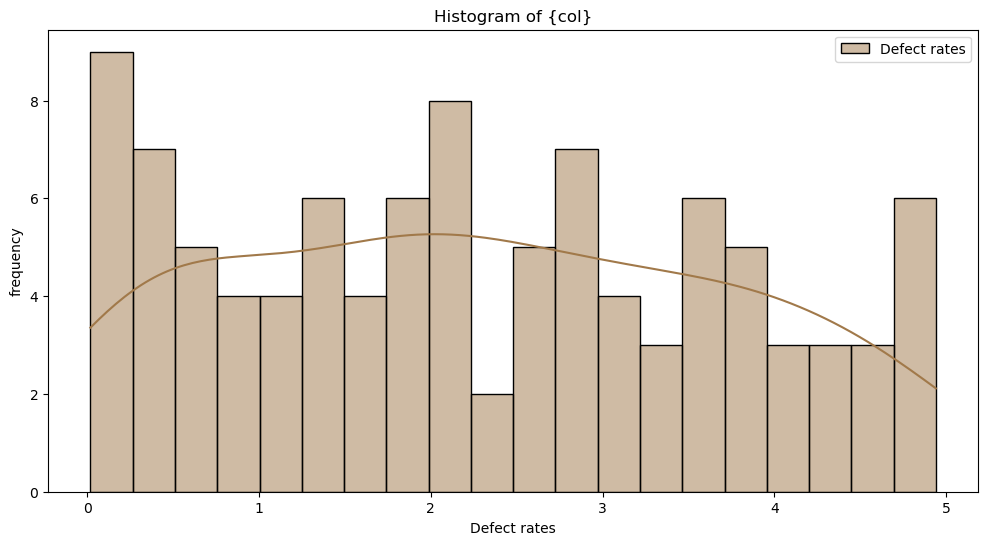

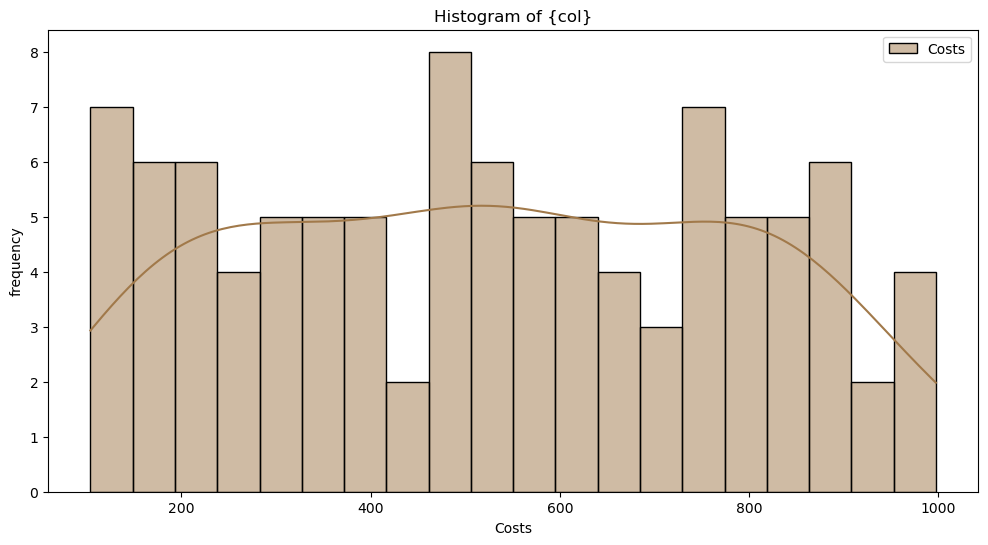

In [13]:
for col in num_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[[col]], kde=True, palette='cubehelix', bins=20)
    plt.title('Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('frequency')
    plt.tight_layout
    plt.show()

### 2. Countplot Of Cat_Cols

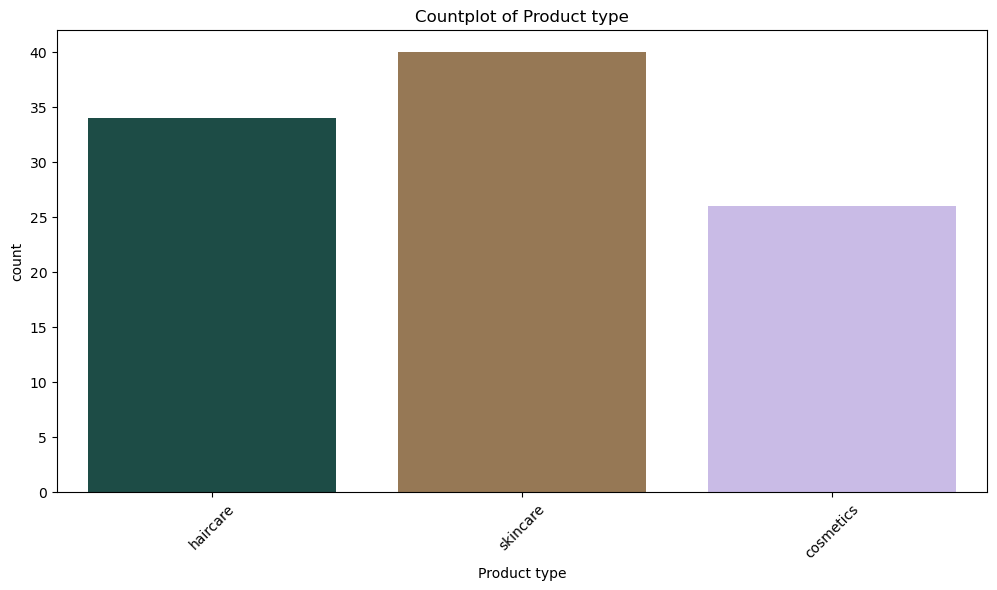

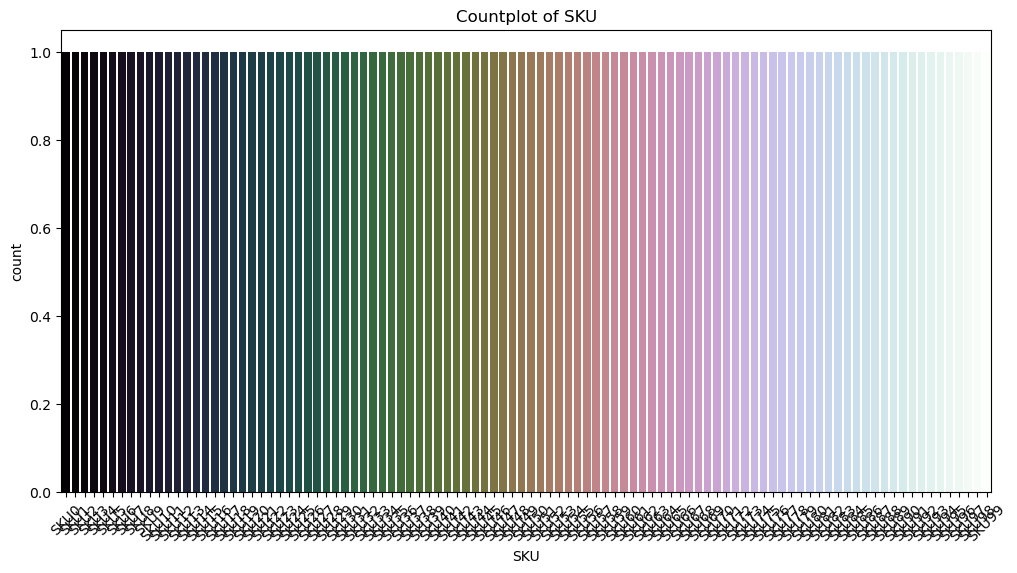

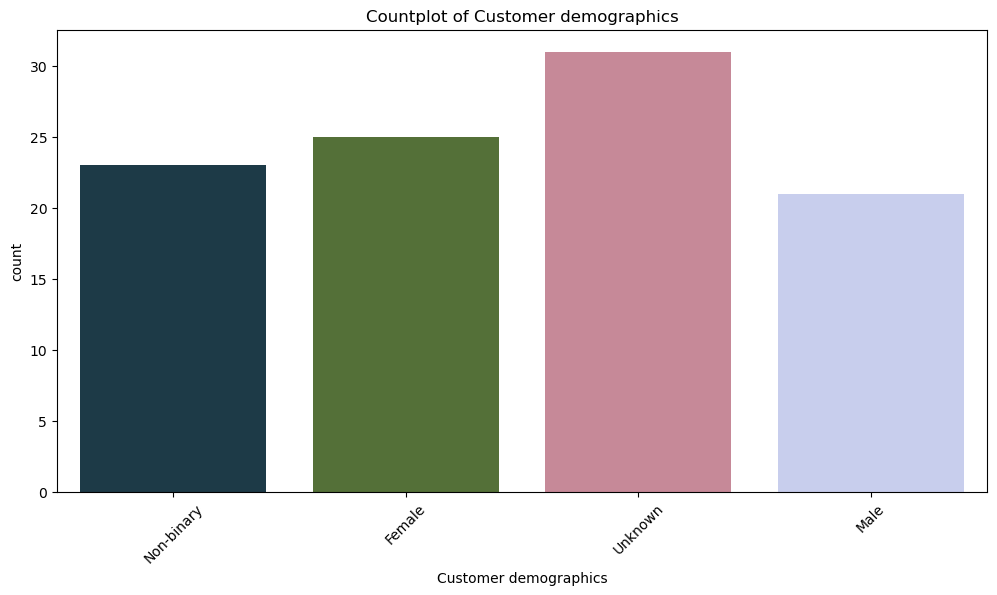

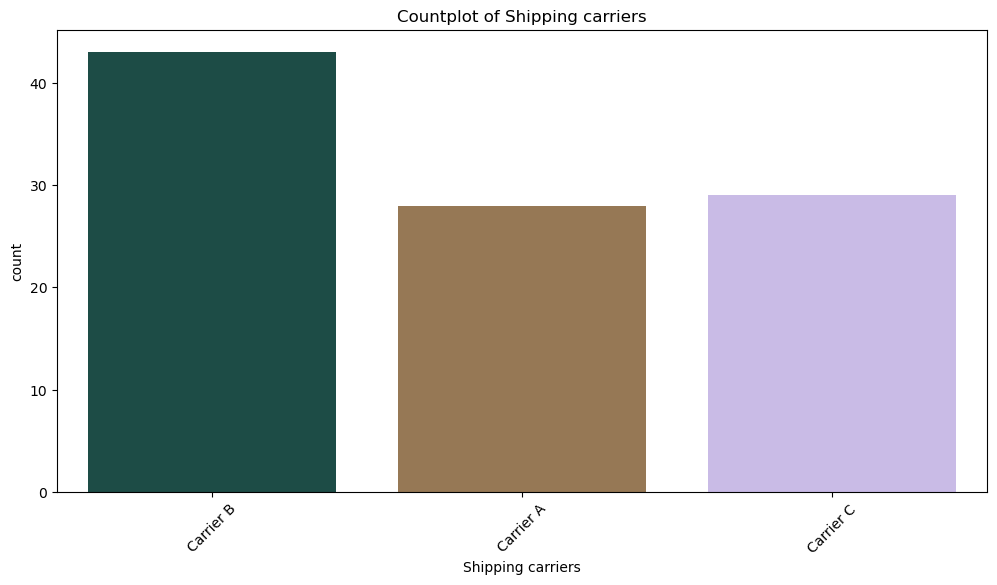

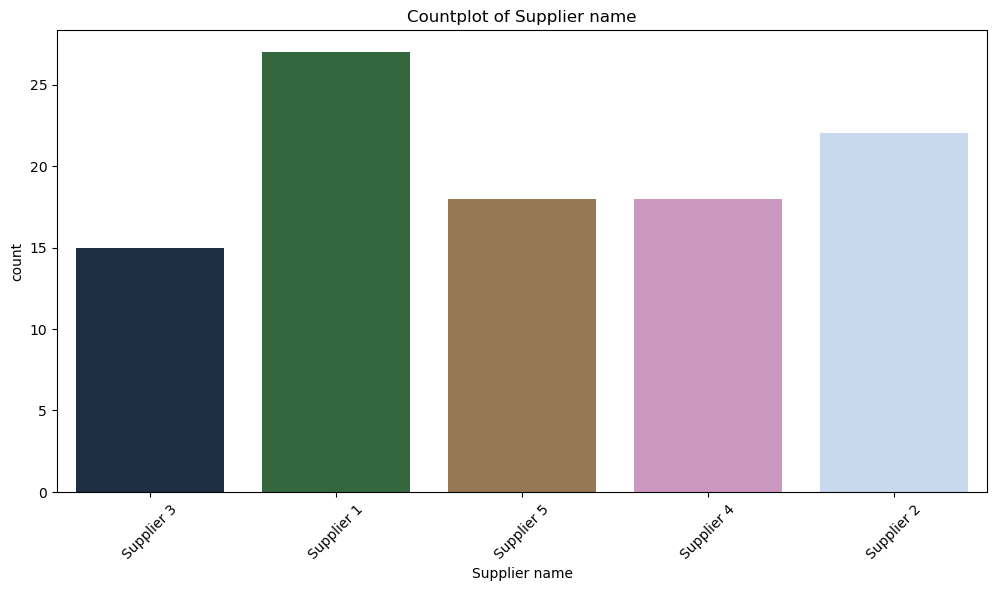

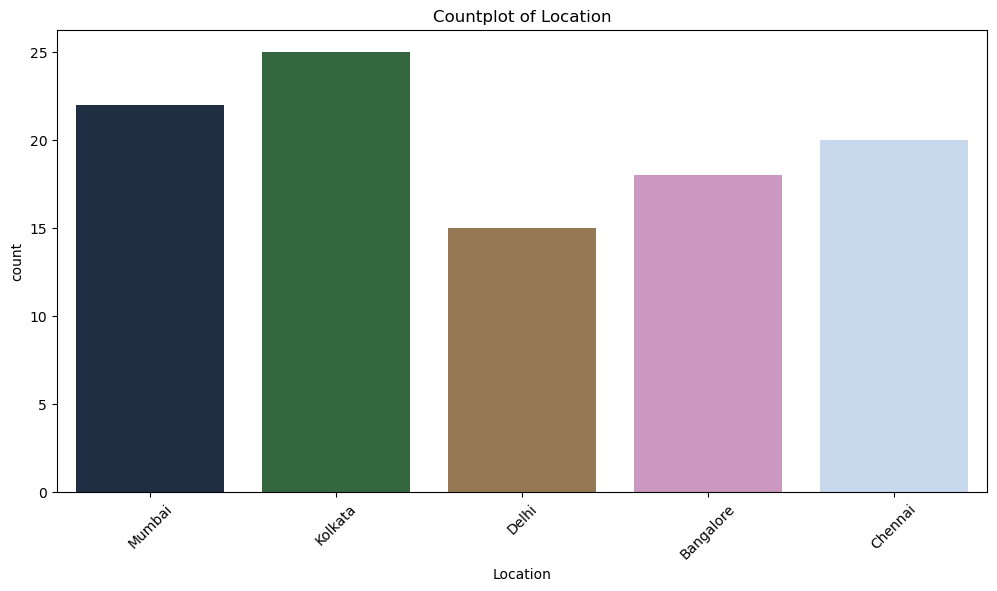

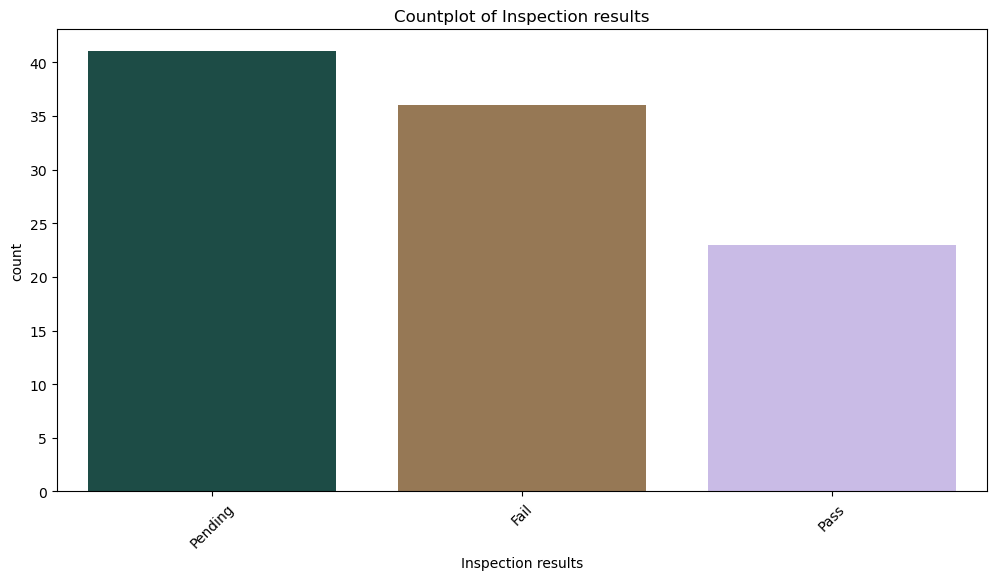

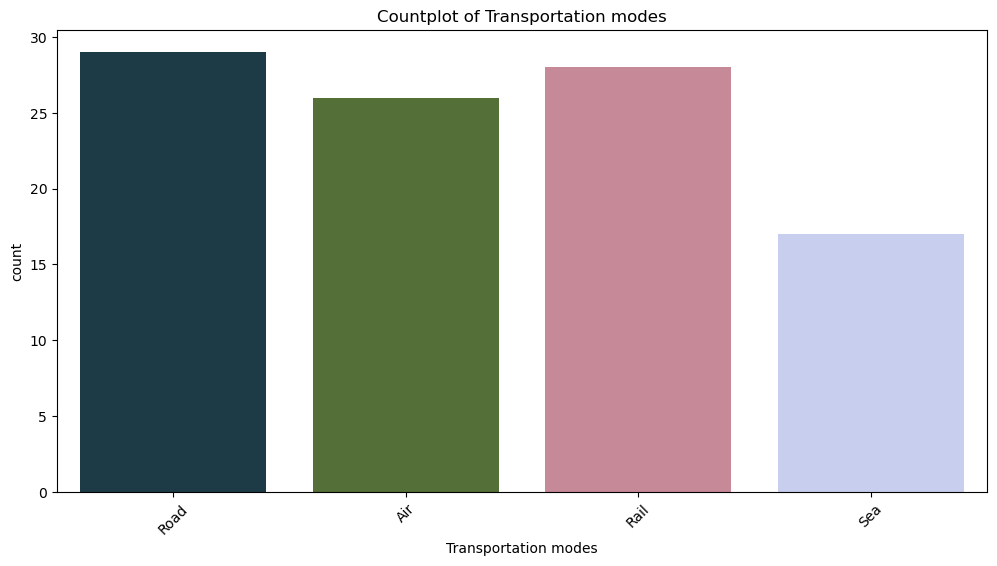

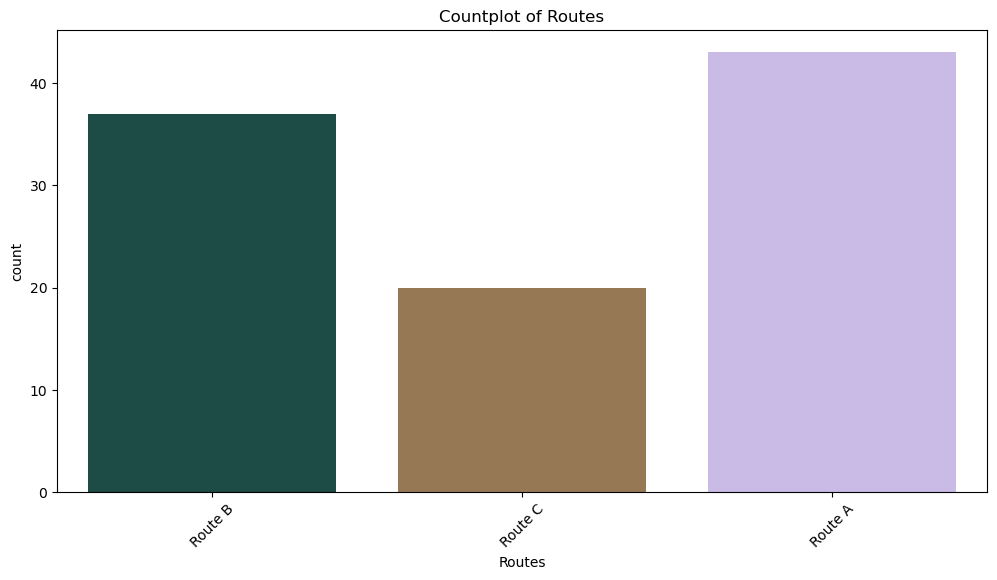

In [14]:
for col in cat_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=col, palette='cubehelix')
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('count')
    plt.xticks(rotation=45)
    plt.tight_layout
    plt.show()

### 3. Price vs Availability By Product Type

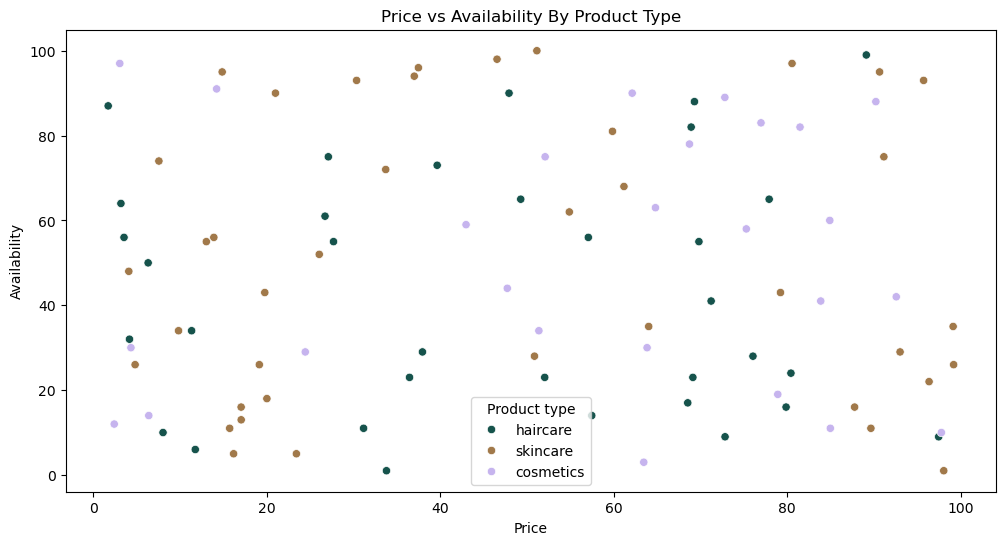

In [16]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['Price'], y=df['Availability'], hue=df['Product type'], palette='cubehelix')
plt.title('Price vs Availability By Product Type')
plt.xlabel('Price')
plt.ylabel('Availability')
plt.show()

### 4. Lead Times vs Manufacturing Lead Times

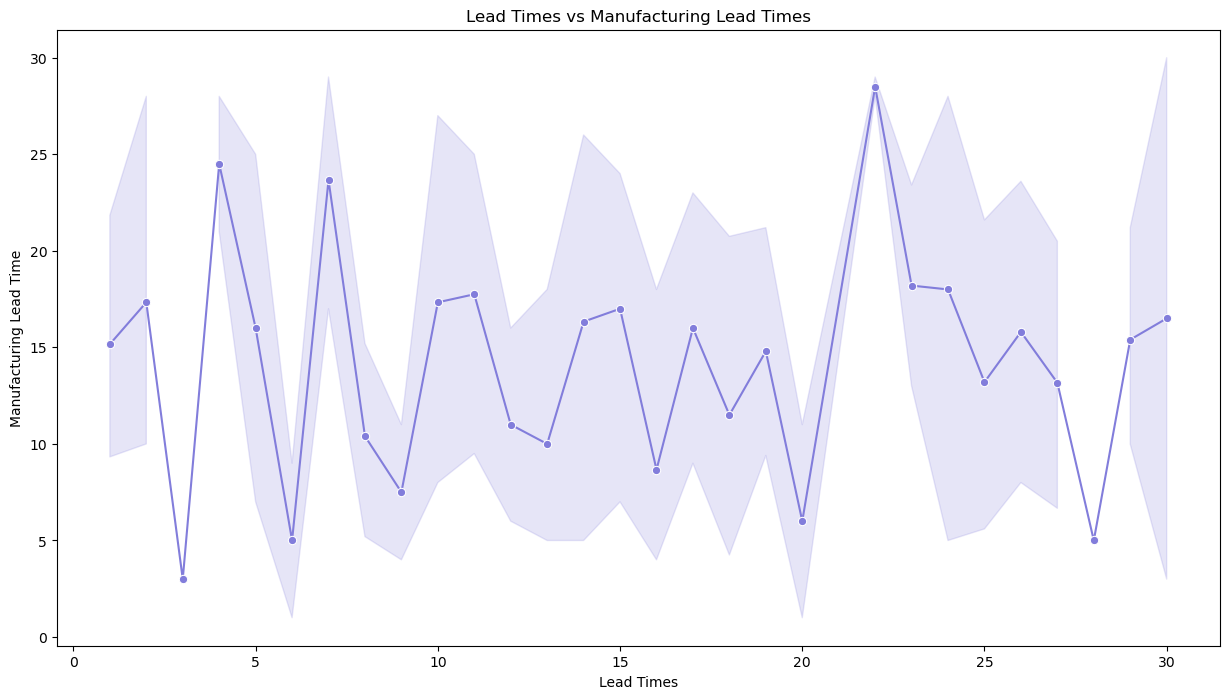

In [24]:
plt.figure(figsize=(15, 8))
sns.lineplot(x=df['Lead times'], y=df['Manufacturing lead time'], marker='o', color='#827DDB')
plt.title('Lead Times vs Manufacturing Lead Times')
plt.xlabel('Lead Times')
plt.ylabel('Manufacturing Lead Time')
plt.show()

### 5. Revenue Generated By Product Type

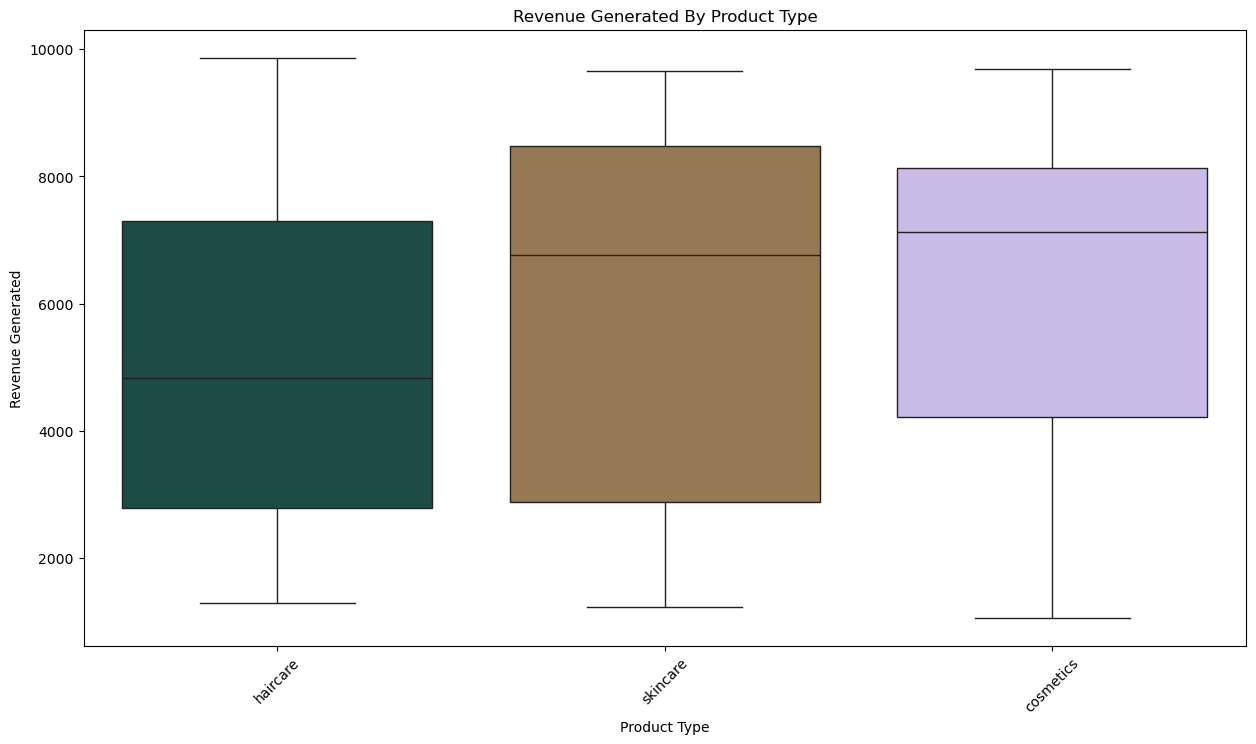

In [28]:
plt.figure(figsize=(15, 8))
sns.boxplot(x=df['Product type'], y=df['Revenue generated'], data=df, palette='cubehelix')
plt.title('Revenue Generated By Product Type')
plt.xlabel('Product Type')
plt.ylabel('Revenue Generated')
plt.xticks(rotation=45)
plt.show()

### 6. Revenue Generated By Transportation Modes

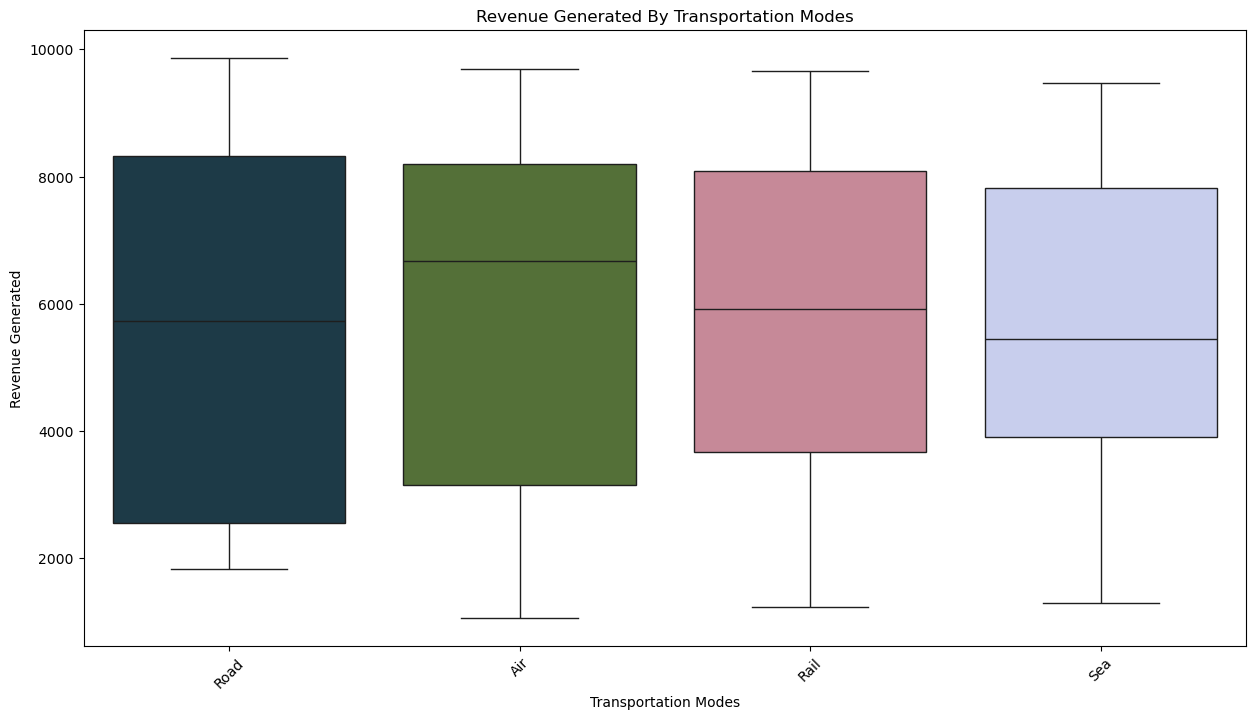

In [29]:
plt.figure(figsize=(15, 8))
sns.boxplot(x=df['Transportation modes'], y=df['Revenue generated'], data=df, palette='cubehelix')
plt.title('Revenue Generated By Transportation Modes')
plt.xlabel('Transportation Modes')
plt.ylabel('Revenue Generated')
plt.xticks(rotation=45)
plt.show()

### 7. Stock Levels vs Lead Times

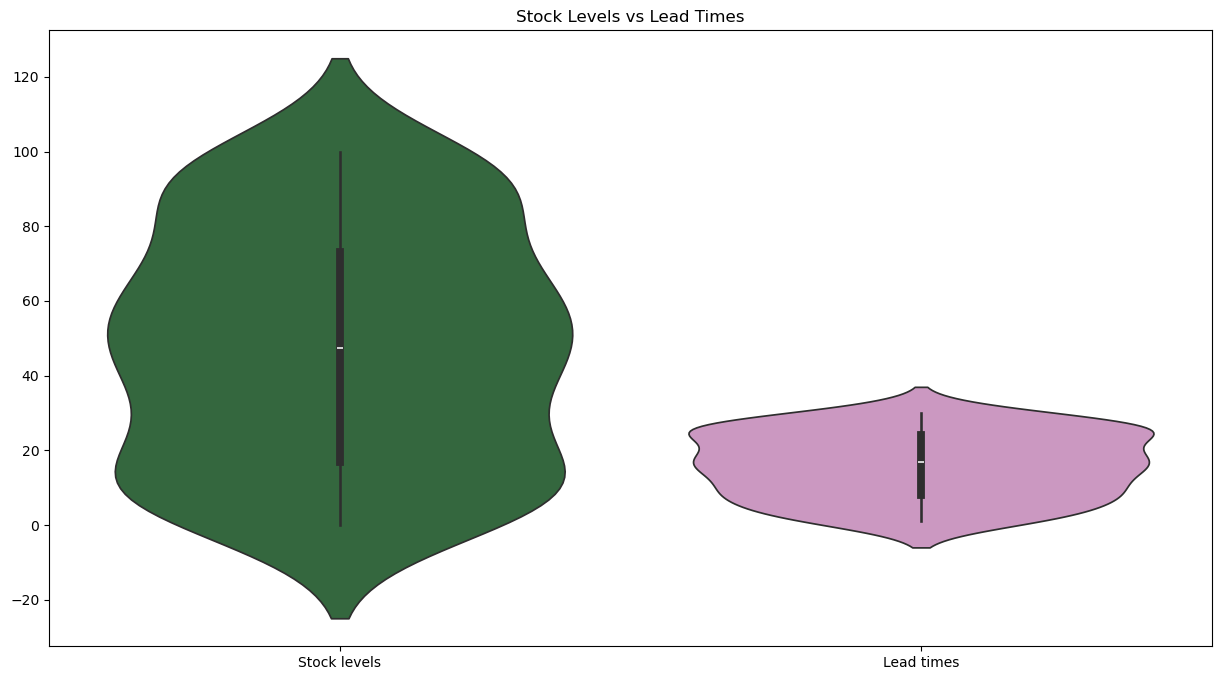

In [31]:
plt.figure(figsize=(15, 8))
sns.violinplot(data=df[['Stock levels','Lead times']], palette='cubehelix')
plt.title('Stock Levels vs Lead Times')
plt.show()

### 8. Correlation Map

In [32]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_df

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
0,69.808006,55,802,8661.996792,58,7,96,4,2.956572,29,215,29,46.279879,0.226410,187.752075
1,14.843523,95,736,7460.900065,53,30,37,2,9.716575,23,517,30,33.616769,4.854068,503.065579
2,11.319683,34,8,9577.749626,1,10,88,2,8.054479,12,971,27,30.688019,4.580593,141.920282
3,61.163343,68,83,7766.836426,23,13,59,6,1.729569,24,937,18,35.624741,4.746649,254.776159
4,4.805496,26,871,2686.505152,5,3,56,8,3.890548,5,414,3,92.065161,3.145580,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,77.903927,65,672,7386.363944,15,14,26,9,8.630339,18,450,26,58.890686,1.210882,778.864241
96,24.423131,29,324,7698.424766,67,2,32,3,5.352878,28,648,28,17.803756,3.872048,188.742141
97,3.526111,56,62,4370.916580,46,19,4,9,7.904846,10,535,13,65.765156,3.376238,540.132423
98,19.754605,43,913,8525.952560,53,1,27,7,1.409801,28,581,9,5.604691,2.908122,882.198864


In [33]:
correlation = numeric_df.corr()

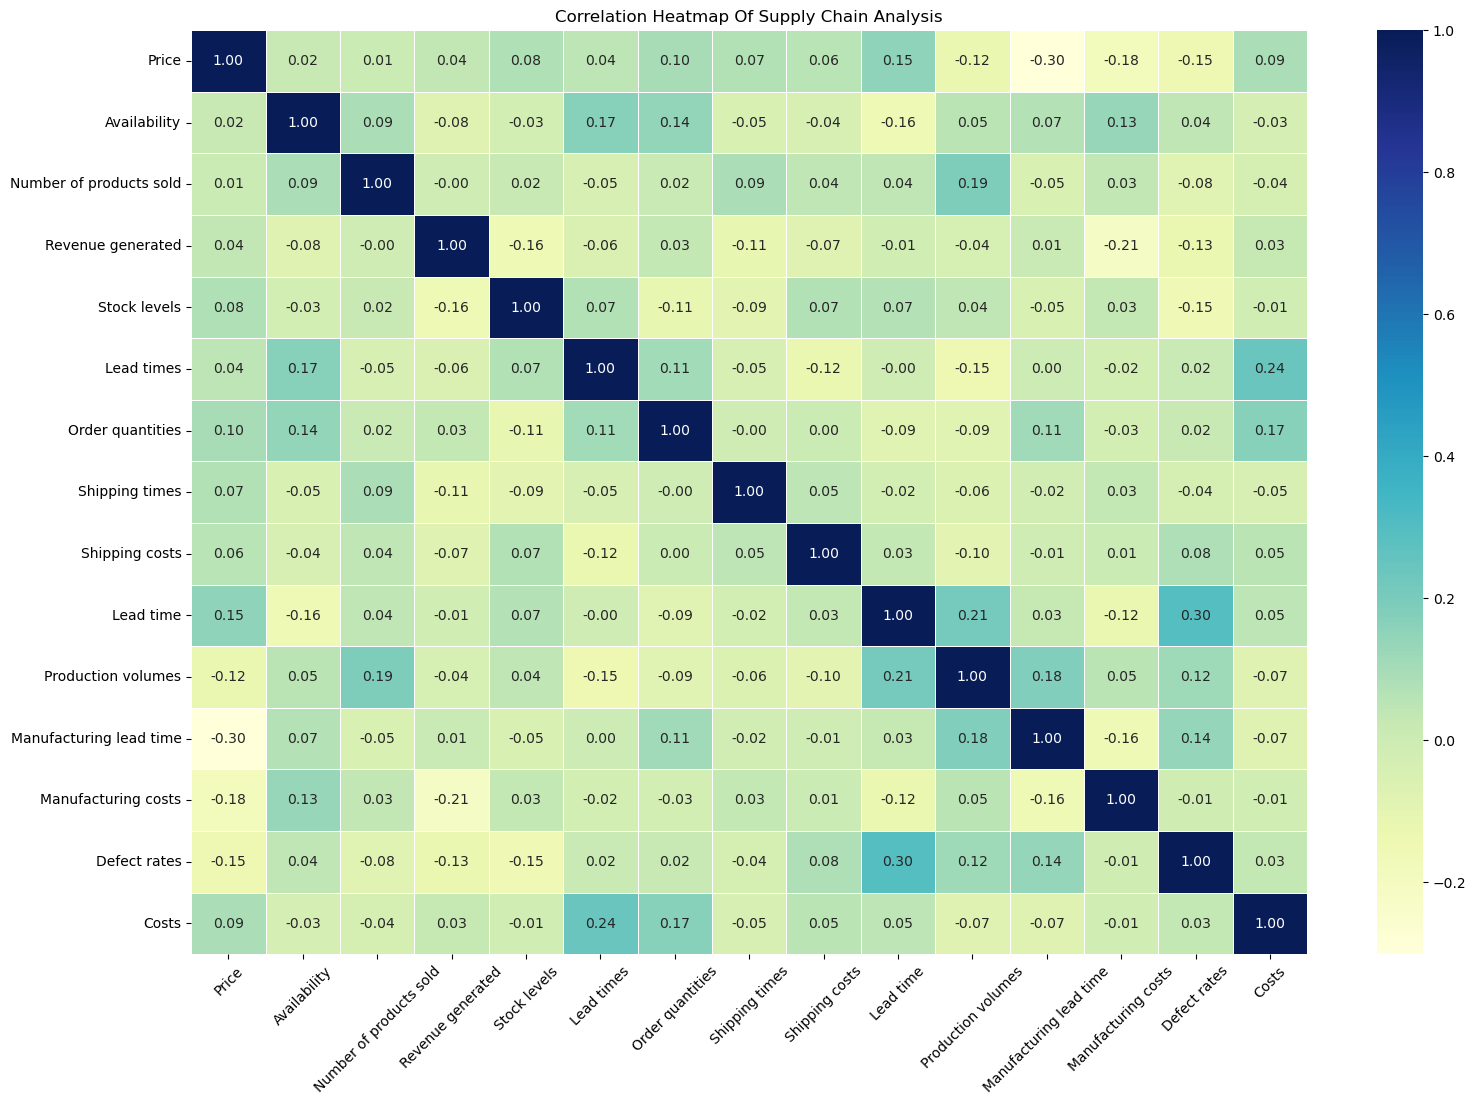

In [35]:
plt.figure(figsize=(18, 12))
sns.heatmap(correlation, annot=True, cmap='YlGnBu', fmt='.2f', linewidth=0.5)
plt.title('Correlation Heatmap Of Supply Chain Analysis')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.show()

## Predictive Modeling

### 1. Train Test Split

In [38]:
df['Product type'].unique()

array(['haircare', 'skincare', 'cosmetics'], dtype=object)

In [39]:
df['Customer demographics'].unique()

array(['Non-binary', 'Female', 'Unknown', 'Male'], dtype=object)

In [40]:
df['Shipping carriers'].unique()

array(['Carrier B', 'Carrier A', 'Carrier C'], dtype=object)

In [41]:
df['Inspection results'].unique()

array(['Pending', 'Fail', 'Pass'], dtype=object)

In [42]:
df['Transportation modes'].unique()

array(['Road', 'Air', 'Rail', 'Sea'], dtype=object)

In [43]:
df['Routes'].unique()

array(['Route B', 'Route C', 'Route A'], dtype=object)

In [45]:
val = {'Product type': {'haircare': 0, 'skincare': 1, 'cosmetics': 2}, 
       'Customer demographics': {'Unknown': 0, 'Male': 1, 'Female': 2, 'Non-binary': 3},
       'Shipping carriers': {'Carrier A': 0, 'Carrier B': 1, 'Carrier C': 2},
       'Inspection results': {'Fail': 0, 'Pass': 1, 'Pending': 2},
       'Transportation modes': {'Road': 0, 'Air': 1, 'Rail': 2, 'Sea': 3},
       'Routes': {'Route A': 0, 'Route B': 1,  'Route C': 2},
       }
df.replace(val, inplace=True)
df

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,0,SKU0,69.808006,55,802,8661.996792,3,58,7,96,...,Mumbai,29,215,29,46.279879,2,0.226410,0,1,187.752075
1,1,SKU1,14.843523,95,736,7460.900065,2,53,30,37,...,Mumbai,23,517,30,33.616769,2,4.854068,0,1,503.065579
2,0,SKU2,11.319683,34,8,9577.749626,0,1,10,88,...,Mumbai,12,971,27,30.688019,2,4.580593,1,2,141.920282
3,1,SKU3,61.163343,68,83,7766.836426,3,23,13,59,...,Kolkata,24,937,18,35.624741,0,4.746649,2,0,254.776159
4,1,SKU4,4.805496,26,871,2686.505152,3,5,3,56,...,Delhi,5,414,3,92.065161,0,3.145580,1,0,923.440632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,SKU95,77.903927,65,672,7386.363944,0,15,14,26,...,Mumbai,18,450,26,58.890686,2,1.210882,1,0,778.864241
96,2,SKU96,24.423131,29,324,7698.424766,3,67,2,32,...,Mumbai,28,648,28,17.803756,2,3.872048,0,0,188.742141
97,0,SKU97,3.526111,56,62,4370.916580,1,46,19,4,...,Mumbai,10,535,13,65.765156,0,3.376238,0,0,540.132423
98,1,SKU98,19.754605,43,913,8525.952560,2,53,1,27,...,Chennai,28,581,9,5.604691,2,2.908122,2,0,882.198864


In [46]:
features = ['Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping costs', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 
            'Defect rates', 'Costs', 'Customer demographics', 'Shipping carriers', 'Inspection results', 'Transportation modes', 'Routes']

target = 'Product type'

X = df[features]
y = df[target]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(80, 20) (20, 20)


### 2. Models

In [51]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Decison Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
}

In [52]:
best_model = None
best_accuracy = 0
best_model_name = ''

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'\n {name} Accuracy: {accuracy}')


 Logistic Regression Accuracy: 0.4

 Decison Tree Accuracy: 0.65

 Random Forest Accuracy: 0.55

 Gradient Boosting Accuracy: 0.55

 K-Nearest Neighbors Accuracy: 0.2


#### Best Model

In [53]:
if accuracy > best_accuracy:
    best_accuracy = accuracy
    best_model = model
    best_model_name = name
    print(f'\n Best Model: {best_model_name} with Accuracy: {best_accuracy}')


 Best Model: K-Nearest Neighbors with Accuracy: 0.2


### 3. Classification Report

In [54]:
y_pred_best = best_model.predict(X_test)
print(f'\n Classification Report: \n', classification_report(y_test, y_pred_best))


 Classification Report: 
               precision    recall  f1-score   support

           0       0.17      0.10      0.12        10
           1       0.30      0.43      0.35         7
           2       0.00      0.00      0.00         3

    accuracy                           0.20        20
   macro avg       0.16      0.18      0.16        20
weighted avg       0.19      0.20      0.19        20



### 4. Confusion Matrix

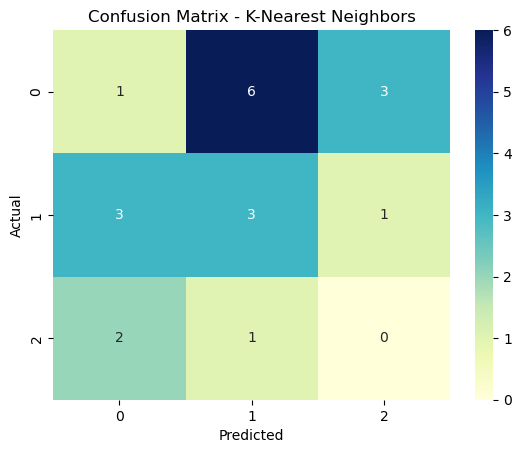

In [57]:
conf_matrix = confusion_matrix(y_test, y_pred_best)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()